### Import libraries

In [1]:
import sys
from pathlib import Path

# go one level up from jupyter_notebooks to project root
project_root = Path().resolve().parent

sys.path.append(str(project_root))

import pandas as pd
from joblib import load
import pipeline.tools as tools
import seaborn as sns
import matplotlib.pyplot as plt

### Untuned model

let's train default *GradientBoostingClassifier* on our data and see how it performs

In [2]:

accuracies_df_fixed_patch = tools.get_sorted_accuracies("GBC", "raw")
accuracies_df_fixed_patch = tools.df_seconds_to_minutes(accuracies_df_fixed_patch)

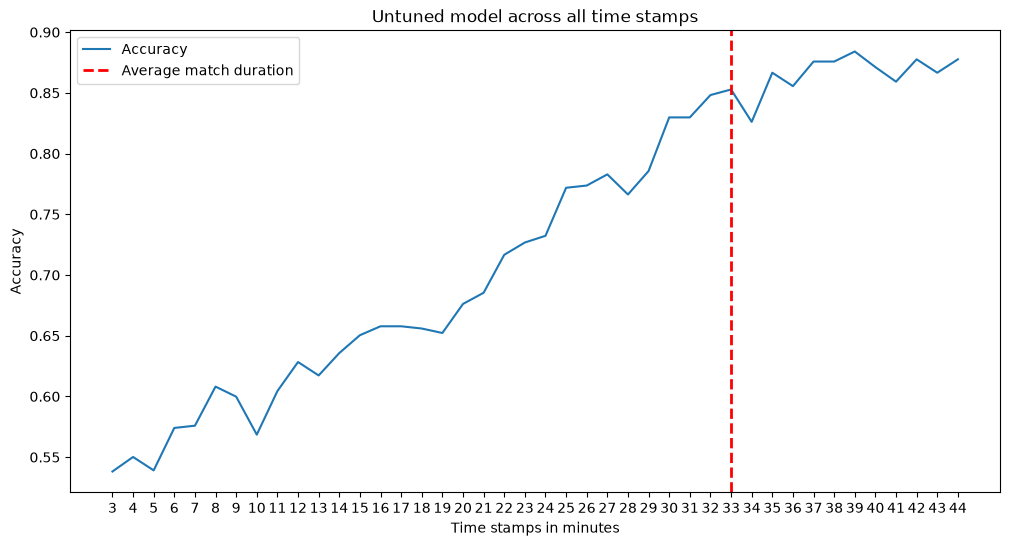

In [3]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(accuracies_df_fixed_patch, x="Time stamps in minutes", y="Accuracy", label="Accuracy")
ax.axvline(x=30, color="red", linestyle="--", linewidth=2, label="Average match duration")
plt.title("Untuned model across all time stamps")
_ = plt.legend()


### Tuned

Let's train *GradientBoostingClassifier* but with Hyperparameter tuning (RandomSearchCV) and see how it performs

In [4]:
accuracies_df_tuned = tools.get_sorted_accuracies("GBC", "tuned")
accuracies_df_tuned = tools.df_seconds_to_minutes(accuracies_df_tuned)

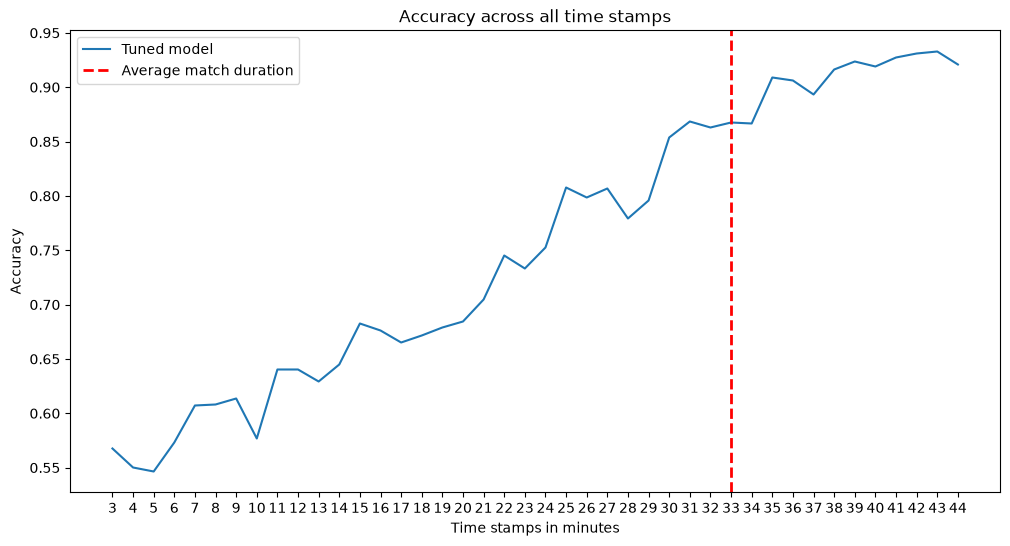

In [5]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(accuracies_df_tuned, x="Time stamps in minutes", y="Accuracy", label="Tuned model")
ax.axvline(x=30, color="red", linestyle="--", linewidth=2, label="Average match duration")
plt.title("Accuracy across all time stamps")
_ = plt.legend()

### Tuned vs Untuned

Let's compare our models and see how much of a difference tuning makes

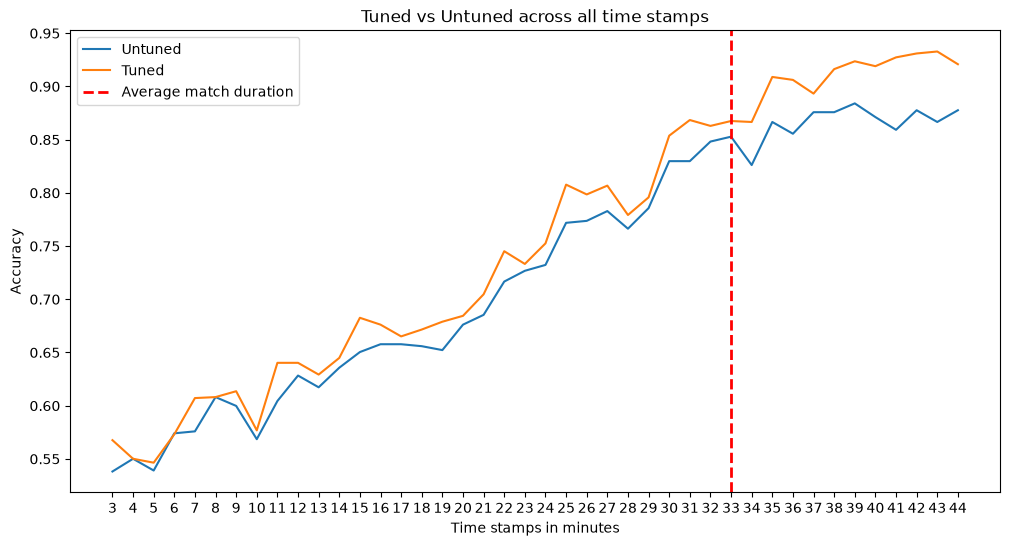

In [6]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(accuracies_df_fixed_patch, x="Time stamps in minutes", y="Accuracy", label="Untuned")
ax = sns.lineplot(accuracies_df_tuned, x="Time stamps in minutes", y="Accuracy", label="Tuned")
ax.axvline(x=30, color="red", linestyle="--", linewidth=2, label="Average match duration")
plt.title("Tuned vs Untuned across all time stamps")
_ = plt.legend()